# Выполнение 6 задания по python

Берем данные из: `5 train.csv`

In [1]:
# Импортируем необходимые библиотеки
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Загружаем данные
df = pd.read_csv("5 train.csv")
df["datetime"] = pd.to_datetime(df["datetime"])

# Выводим информацию
print("Размер датасета:", df.shape)
df.head()

Размер датасета: (10886, 12)


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


## 1. Найдите час суток с максимальным числом поездок в выходные дни

In [3]:
# сохраняем только выходные дни
weekend = df[df["workingday"] == 0]

# группировка по часам и вычисление среднего количества поездок
hour_weekend = weekend.groupby(weekend["datetime"].dt.hour).agg({"count": "mean"})
hour_weekend.columns = ["Среднее число поездок"]

hour_weekend.sort_values("Среднее число поездок")

,Среднее число поездок
datetime,
4,8.544828
5,9.373239
6,19.993103
3,25.534722
7,47.268966
2,53.748252
1,71.910345
23,90.606897
0,94.489655


In [4]:
best_hour = hour_weekend["Среднее число поездок"].idxmax()
best_value = hour_weekend["Среднее число поездок"].max()

print("Час с наибольшим количеством поездок в выходные дни:", best_hour)
print("Среднее число поездок:", round(best_value, 2))

Час с наибольшим количеством поездок в выходные дни: 13
Среднее число поездок: 387.82


## 2. Постройте столбчатую диаграмму: среднее число поездок (`casual` и `registered`) по сезонам

In [5]:
# группируем данные по сезонам, округляем до 2 знаков после запятой
season_stats = df.groupby("season")[["casual", "registered"]].mean().round(2)
# задаем названия сезонов
season_stats.index = ["Зима", "Весна", "Лето", "Осень"]
# выводим результат
season_stats

,casual,registered
Зима,15.49,100.85
Весна,47.45,167.80
Лето,52.22,182.20
Осень,28.58,170.41


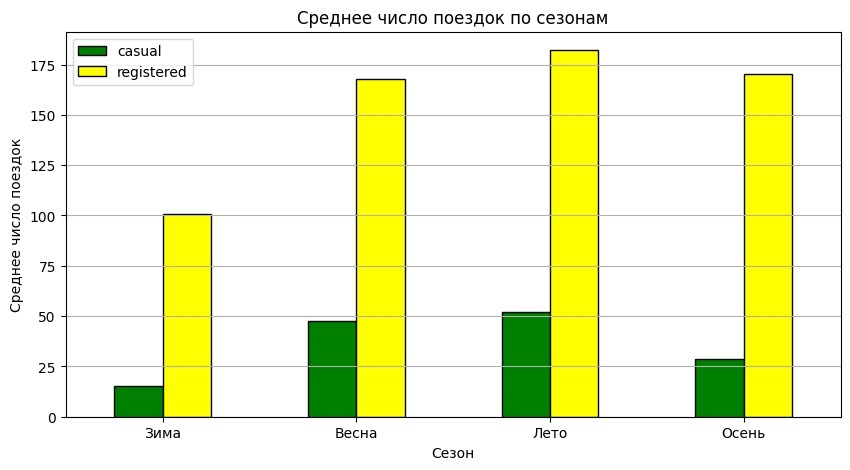

In [6]:
# создаем столбчатую диаграмму для сравнения casual и registered по сезонам
season_stats.plot(
    kind="bar",
    figsize=(10, 5),
    color=["green", "yellow"],
    edgecolor="black"
)
plt.title("Среднее число поездок по сезонам")
plt.xlabel("Сезон")
plt.ylabel("Среднее число поездок")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

## 3. Фильтр: найдите все наблюдения, где `count > 500` — сколько их? В какое время года чаще всего?

In [7]:
# фильтруем наблюдения с количеством поездок больше 500
big_count = df[df["count"] > 500]
print("Количество наблюдений:", len(big_count))

big_count.head()

Количество наблюдений: 797


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
1819,2011-05-02 17:00:00,2,0,1,1,27.06,31.060,65,12.9980,65,472,537
1820,2011-05-02 18:00:00,2,0,1,2,26.24,30.305,65,12.9980,68,450,518
1843,2011-05-03 17:00:00,2,0,1,1,28.70,32.575,54,31.0009,53,464,517
1844,2011-05-03 18:00:00,2,0,1,1,28.70,32.575,48,27.9993,59,485,544
1891,2011-05-05 17:00:00,2,0,1,1,22.96,26.515,26,26.0027,66,467,533


In [8]:
# подсчитываем количество наблюдений для каждого сезона и сортируем по индексу
season_counts = big_count["season"].value_counts().sort_index()
season_counts.index = ["Зима", "Весна", "Лето", "Осень"]
season_counts

Зима      59
Весна    281
Лето     271
Осень    186
Name: count, dtype: int64

Больше всего наблюдений встречается весной

## 4. Сохраните в CSV таблицу: средняя температура и среднее число поездок по каждому месяцу

In [9]:
# группируем по месяцам и вычисляем среднюю температуру и количество поездок, округляем до 2 знаков после запятой
monthly_stats = df.groupby(df["datetime"].dt.to_period("M")).agg({
    "temp": "mean",
    "count": "mean"
}).round(2)

# задаем названия столбцов и индекс
monthly_stats.columns = ["avg_temp", "avg_count"]
monthly_stats.index = monthly_stats.index.astype(str)
monthly_stats.index.name = "month"

monthly_stats.head()

,avg_temp,avg_count
month,,
2011-01,8.63,54.65
2011-02,11.33,73.64
2011-03,14.06,86.85
2011-04,17.78,111.03
2011-05,21.53,174.81


Сохраняем в .csv

In [10]:
monthly_stats.to_csv("data.csv", sep=";")